## Building a CNN Model for Image Classification 

### Part A: Data Understanding & Preprocessing

#### 1. Load the dataset and explore its structure (number of classes, sample images, image sizes). 
#### 2. Perform data preprocessing steps: 
- Resize all images to a common size (e.g., 150×150). 
- Normalize pixel values. 
- Split dataset into train, validation, and test sets. 
- Apply data augmentation (rotation, flip, zoom, shift, etc.) to improve generalization.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

In [12]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    'seg_train/seg_train',
    target_size=(150, 150),
    batch_size=32,
    subset='training',
    class_mode='categorical'
)
val_data = train_datagen.flow_from_directory(
    'seg_train/seg_train',
    target_size=(150, 150),
    batch_size=32,
    subset='validation',
    class_mode='categorical'
)
test_data = test_datagen.flow_from_directory(
    'seg_test/seg_test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)
num_classes = len(train_data.class_indices)
print("Number of classes", num_classes)
print("Class labels:", train_data.class_indices)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Number of classes 6
Class labels: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


#### Display Sample Images

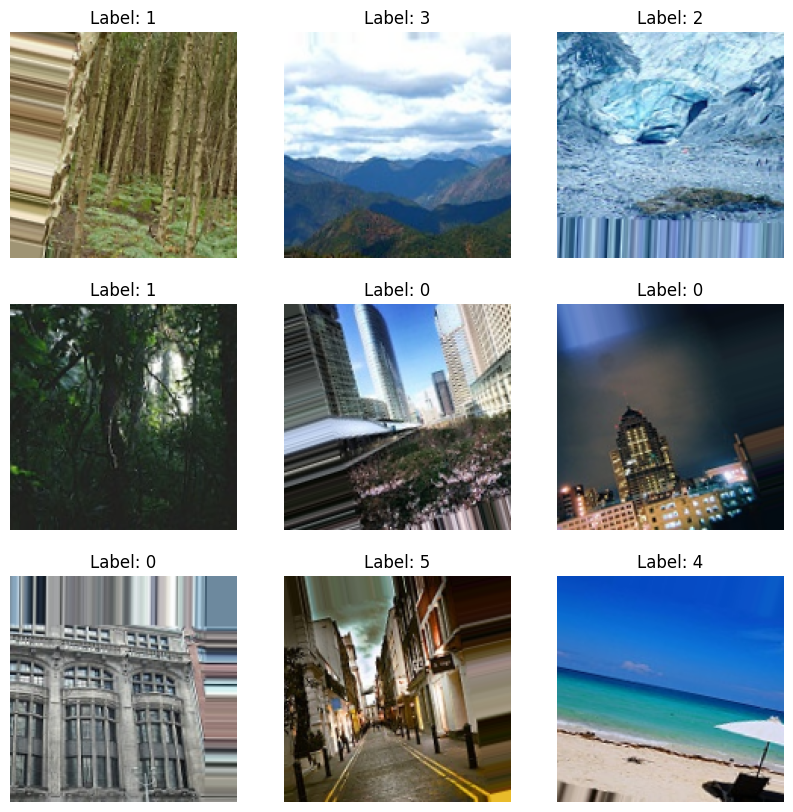

In [13]:
images, labels = next(train_data)
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.title(f"Label: {labels[i].argmax()}")
    plt.axis('off')
plt.show()

#### Check Image Shape

In [14]:
print("Image shape:", images[0].shape)

Image shape: (150, 150, 3)


### Part B: CNN Model Development

#### 3. Build a Convolutional Neural Network (CNN) from scratch using TensorFlow/Keras or PyTorch. 
- Minimum 3 convolutional layers. 
- Use activation functions (ReLU, softmax). 
- Apply pooling layers (max pooling/average pooling). 
- Add fully connected layers and dropout for regularization.

In [15]:
from tensorflow.keras import layers, models

model = models.Sequential()

# Input Layer 
model.add(layers.Input(shape=(150,150,3)))

# Conv Layer 1
model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Conv Layer 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Conv Layer 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Flatten + Dense
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(6, activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

#### Compile Model

In [16]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

##### Callbacks

In [17]:
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

checkpoint = ModelCheckpoint("best_model.keras", save_best_only=True)

#### Train Model

In [18]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 672s 2s/step - accuracy: 0.5103 - loss: 1.2312 - val_accuracy: 0.6070 - val_loss: 1.0281
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 657s 2s/step - accuracy: 0.6188 - loss: 0.9923 - val_accuracy: 0.6715 - val_loss: 0.8833
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 684s 2s/step - accuracy: 0.6654 - loss: 0.8948 - val_accuracy: 0.7136 - val_loss: 0.8074
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 549s 1s/step - accuracy: 0.6921 - loss: 0.8363 - val_accuracy: 0.7471 - val_loss: 0.7310
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 1439s 4s/step - accuracy: 0.7170 - loss: 0.7657 - val_accuracy: 0.7550 - val_loss: 0.7008
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 551s 2s/step - accuracy: 0.7383 - loss: 0.7274 - val_accuracy: 0.7718 - val_loss: 0.6366
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 453s 1s/step - accuracy: 0.7457 - loss: 0.6944 - val_accuracy: 0.7874 - val_loss: 0.6042
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 502s 1s/step - accuracy: 0.7652 - loss: 0.6567 - val_acc

#### Plot Accuracy & Loss

#### 4. Train the CNN model on the training dataset and validate it on the validation set. 
- Plot training vs. validation loss and accuracy curves. 
- Use early stopping and model checkpointing if necessary.

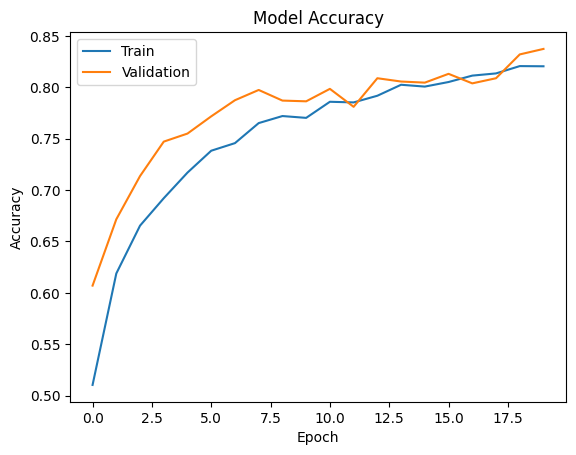

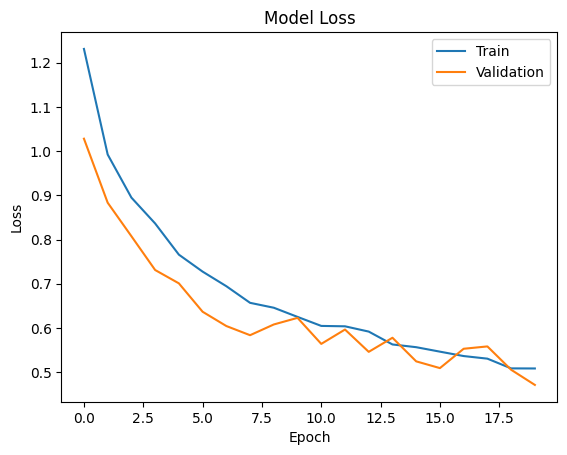

In [19]:
# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

### Part C: Model Evaluation and Interpretation

#### 5. Evaluate the model on the test set and report performance metrics: 
- Accuracy 
- Precision, Recall, F1-score per class 
- Confusion Matrix

##### Evaluate Model

In [21]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 30s 320ms/step - accuracy: 0.8583 - loss: 0.4270
Test Accuracy: 0.8583333492279053


##### Predictions

In [22]:
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_data.classes

94/94 ━━━━━━━━━━━━━━━━━━━━ 23s 244ms/step


##### Classification Report

In [23]:
class_labels = list(test_data.class_indices.keys())

print(classification_report(y_true, y_pred_classes, target_names=class_labels))

              precision    recall  f1-score   support

   buildings       0.15      0.17      0.16       437
      forest       0.17      0.17      0.17       474
     glacier       0.17      0.17      0.17       553
    mountain       0.15      0.12      0.13       525
         sea       0.16      0.18      0.17       510
      street       0.15      0.15      0.15       501

    accuracy                           0.16      3000
   macro avg       0.16      0.16      0.16      3000
weighted avg       0.16      0.16      0.16      3000



##### Confusion Matrix

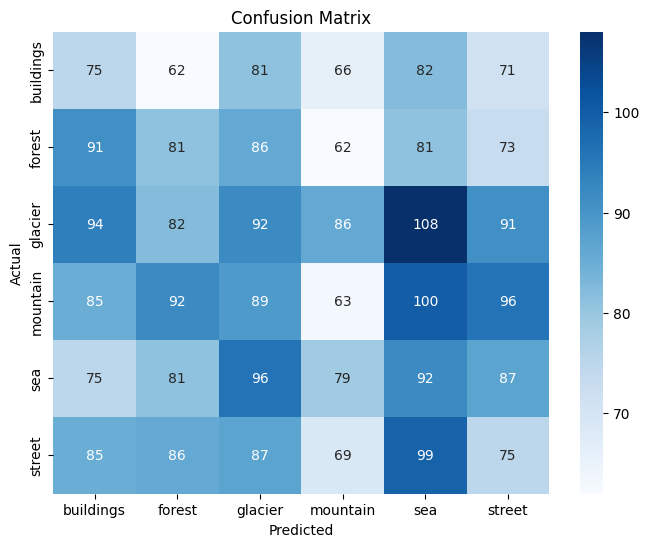

In [24]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### 6. Visualize predictions for at least 10 random test images with predicted vs. actual labels.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


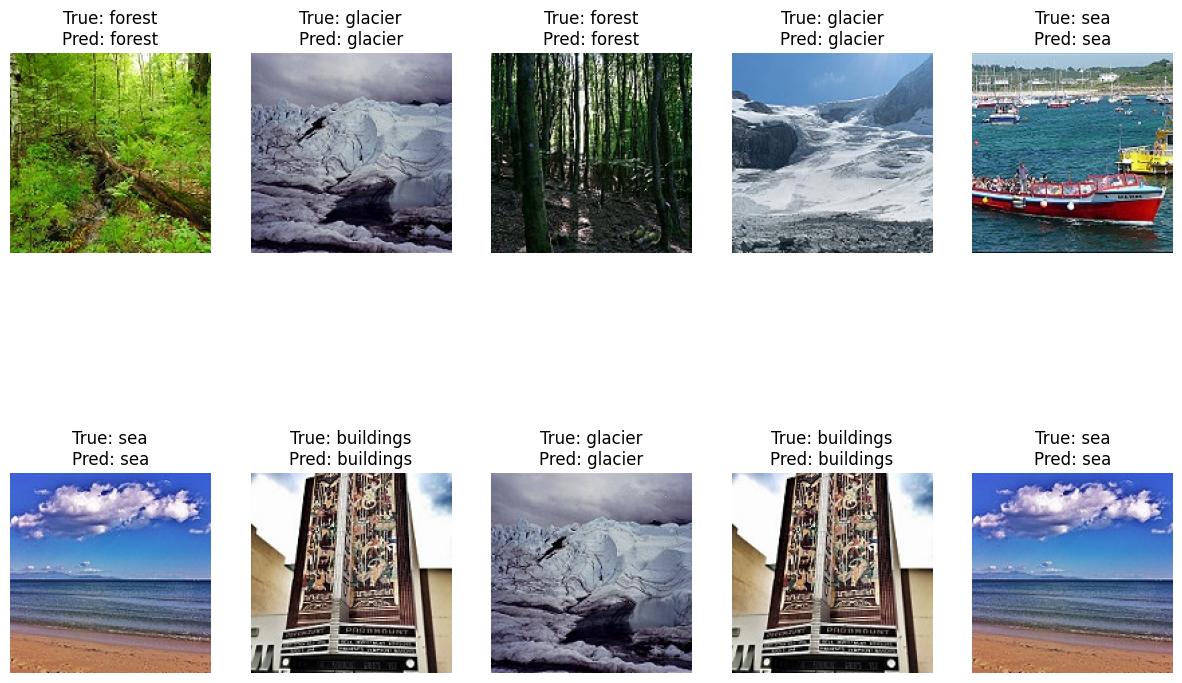

In [25]:
import random

images, labels = next(test_data)

plt.figure(figsize=(15,10))

for i in range(10):
    idx = random.randint(0, len(images)-1)
    
    img = images[idx]
    true_label = class_labels[np.argmax(labels[idx])]
    pred_label = class_labels[np.argmax(model.predict(img.reshape(1,150,150,3)))]
    
    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')

plt.show()